In [12]:
# Import required libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv('/Users/nk/Downloads/GNN/xtrium-material-gnn/data/processed/nasa_materials_export.csv')

In [14]:
df.shape

(1549, 1287)

In [15]:
df.head()

,Id,Material_Name,Database_Source,Category,URL,Name,Database,Composition,Manufacturer,Technical_Readiness_Level,...,Bending_Strength_In_Plane_6_Last_Modified,Coefficient_of_Thermal_Expansion_Isotropic_7_Uncertainty,Coefficient_of_Thermal_Expansion_Isotropic_7_Reference,Electrical_Resistivity8_Value,Electrical_Resistivity8_Units,Electrical_Resistivity8_Uncertainty,Electrical_Resistivity8_Source,Electrical_Resistivity8_STP,Electrical_Resistivity8_Reference,Electrical_Resistivity8_Last_Modified
0,1,"1/4"" Rohacell 31 foam/carbon cloth Aircraft Sk...",NASA Langley Research Center Database,Structural Organic Composites | Description:,https://tpsx.arc.nasa.gov/Material?id=1547,"1/4"" Rohacell 31 foam/carbon cloth Aircraft Sk...",NASA Langley Research Center Database | Descri...,Description:,Description:,4 | Description:,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,"1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...",NASA Langley Research Center Database,Polyamides | Description:,https://tpsx.arc.nasa.gov/Material?id=1437,"1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...",NASA Langley Research Center Database | Descri...,"Composition of BMDEDA - 1,3-Bis(3,4-dicarboxyp...","1,3-Bis(4-hydroxyphenyl-2-propyl)benzene (bish...",Description:,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,"1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...",NASA Langley Research Center Database,Polyamides | Description:,https://tpsx.arc.nasa.gov/Material?id=1441,"1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...",NASA Langley Research Center Database | Descri...,"Composition of BMDEDA - 1,3-Bis(3,4-dicarboxyp...","1,3-Bis(4-hydroxyphenyl-2-propyl)benzene (bish...",Description:,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,"1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...",NASA Langley Research Center Database,Polyamides | Description:,https://tpsx.arc.nasa.gov/Material?id=1440,"1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...",NASA Langley Research Center Database | Descri...,"Composition of BMDEDA - 1,3-Bis(3,4-dicarboxyp...","1,3-Bis(4-hydroxyphenyl-2-propyl)benzene (bish...",Description:,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,"1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...",NASA Langley Research Center Database,Polyamides | Description:,https://tpsx.arc.nasa.gov/Material?id=1438,"1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...",NASA Langley Research Center Database | Descri...,"Composition of BMDEDA - 1,3-Bis(3,4-dicarboxyp...","1,3-Bis(4-hydroxyphenyl-2-propyl)benzene (bish...",Description:,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.isnull().sum()
df.describe()
df.info()
df.columns
df.dtypes



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1549 entries, 0 to 1548
Columns: 1287 entries, Id to Electrical_Resistivity8_Last_Modified
dtypes: float64(466), int64(1), object(820)
memory usage: 15.2+ MB


Id                                         int64
Material_Name                             object
Database_Source                           object
Category                                  object
URL                                       object
                                          ...   
Electrical_Resistivity8_Uncertainty      float64
Electrical_Resistivity8_Source            object
Electrical_Resistivity8_STP               object
Electrical_Resistivity8_Reference        float64
Electrical_Resistivity8_Last_Modified     object
Length: 1287, dtype: object

MISSING VALUES ANALYSIS

Total columns: 1287
Columns with missing values: 1282
Columns with no missing values: 5

Overall data completeness: 2.46%

Top 30 columns with highest missing values:


,Column,Missing Count,Missing Percentage
643,Blowing_Correction_laminar_shear_Value,1548,99.935442
874,Poisson_s_Ratio_In_Plane_16_STP,1548,99.935442
863,Shear_Modulus_In_Plane_14_Source,1548,99.935442
864,Shear_Modulus_In_Plane_14_STP,1548,99.935442
865,Shear_Modulus_In_Plane_14_Last_Modified,1548,99.935442
866,Poisson_s_Ratio_Thru_the_Thickness_15_Value,1548,99.935442
867,Poisson_s_Ratio_Thru_the_Thickness_15_Units,1548,99.935442
868,Poisson_s_Ratio_Thru_the_Thickness_15_Source,1548,99.935442
869,Poisson_s_Ratio_Thru_the_Thickness_15_STP,1548,99.935442
870,Poisson_s_Ratio_Thru_the_Thickness_15_Last_Mod...,1548,99.935442


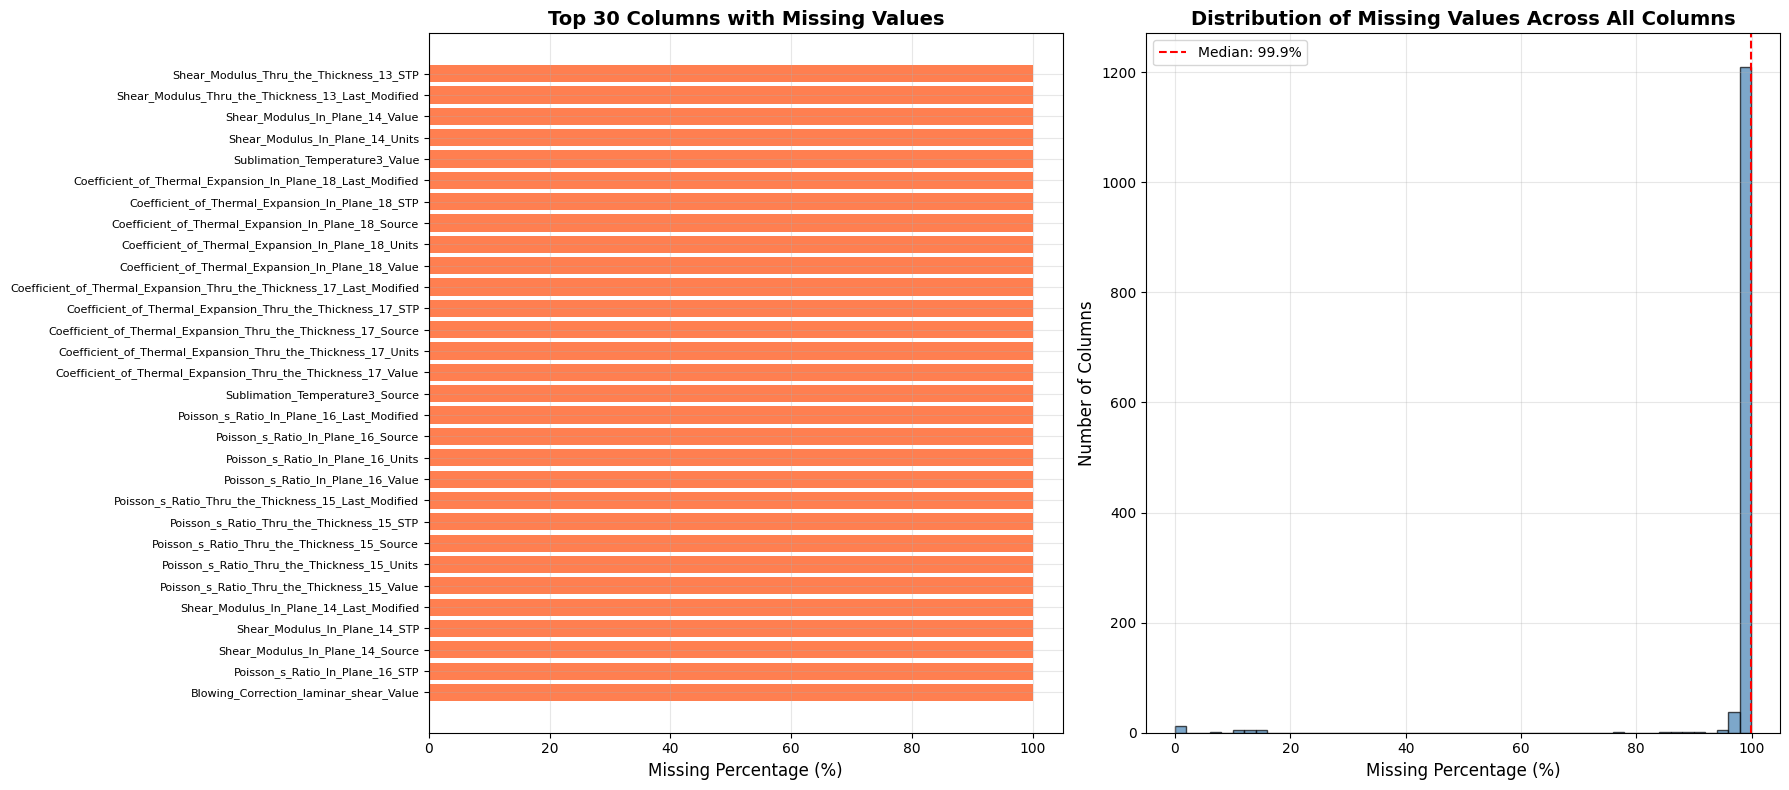

In [17]:
# Missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
}).sort_values('Missing Percentage', ascending=False)

print(f"\nTotal columns: {len(df.columns)}")
print(f"Columns with missing values: {len(missing_df[missing_df['Missing Count'] > 0])}")
print(f"Columns with no missing values: {len(missing_df[missing_df['Missing Count'] == 0])}")
print(f"\nOverall data completeness: {(1 - missing_df['Missing Count'].sum() / (len(df) * len(df.columns))) * 100:.2f}%")

print(f"\nTop 30 columns with highest missing values:")
display(missing_df.head(30))

# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 30 missing columns
top_missing = missing_df.head(30)
axes[0].barh(range(len(top_missing)), top_missing['Missing Percentage'], color='coral')
axes[0].set_yticks(range(len(top_missing)))
axes[0].set_yticklabels(top_missing['Column'], fontsize=8)
axes[0].set_xlabel('Missing Percentage (%)', fontsize=12)
axes[0].set_title('Top 30 Columns with Missing Values', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Missing value distribution histogram
axes[1].hist(missing_percent, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Missing Percentage (%)', fontsize=12)
axes[1].set_ylabel('Number of Columns', fontsize=12)
axes[1].set_title('Distribution of Missing Values Across All Columns', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(missing_percent.median(), color='red', linestyle='--', 
                label=f'Median: {missing_percent.median():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Identify column types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Further categorize text vs categorical
# High cardinality (>50 unique values) = text, low cardinality = categorical
text_cols = []
cat_cols = []

for c in categorical_cols:
    if df[c].notna().sum() > 0:
        unique_count = df[c].nunique()
        if unique_count > 50:
            text_cols.append(c)
        else:
            cat_cols.append(c)
    else:
        cat_cols.append(c)  # All NaN columns go to categorical

print("=" * 80)
print("COLUMN CATEGORIZATION")
print("=" * 80)
print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns (low cardinality ≤50): {len(cat_cols)}")
print(f"Text columns (high cardinality >50): {len(text_cols)}")
print(f"\nSample numeric columns (first 15):")
for i, col in enumerate(numeric_cols[:15], 1):
    non_null = df[col].notna().sum()
    print(f"{i:2d}. {col} (non-null: {non_null})")
print(f"\nSample categorical columns (first 15):")
for i, col in enumerate(cat_cols[:15], 1):
    unique_vals = df[col].nunique()
    print(f"{i:2d}. {col} (unique values: {unique_vals})")
print(f"\nText columns: {text_cols[:10]}...")


COLUMN CATEGORIZATION

Numeric columns: 467
Categorical columns (low cardinality ≤50): 810
Text columns (high cardinality >50): 10

Sample numeric columns (first 15):
 1. Id (non-null: 1549)
 2. Density_Value (non-null: 1392)
 3. Density_Uncertainty (non-null: 30)
 4. Density_Reference (non-null: 204)
 5. Thermal_Conductivity_Thru_the_Thickness_Value (non-null: 60)
 6. Thermal_Conductivity_Thru_the_Thickness_Uncertainty (non-null: 10)
 7. Thermal_Conductivity_Thru_the_Thickness_Reference (non-null: 49)
 8. Thermal_Conductivity_In_Plane_Value (non-null: 51)
 9. Thermal_Conductivity_In_Plane_Uncertainty (non-null: 5)
10. Thermal_Conductivity_In_Plane_Reference (non-null: 40)
11. Specific_Heat_Value (non-null: 1359)
12. Specific_Heat_Uncertainty (non-null: 12)
13. Specific_Heat_Reference (non-null: 179)
14. Tensile_Strength_Isotropic_1_Value (non-null: 25)
15. Tensile_Strength_Isotropic_1_Uncertainty (non-null: 25)

Sample categorical columns (first 15):
 1. Database_Source (unique values

In [19]:
# Extract key material property columns
# Properties typically have pattern: PropertyName_Value, PropertyName_Units, PropertyName_Source, etc.

property_value_cols = [col for col in df.columns if col.endswith('_Value') and col in numeric_cols]
property_units_cols = [col for col in df.columns if col.endswith('_Units')]
property_source_cols = [col for col in df.columns if col.endswith('_Source')]
property_uncertainty_cols = [col for col in df.columns if col.endswith('_Uncertainty') and col in numeric_cols]

print("=" * 80)
print("MATERIAL PROPERTIES IDENTIFICATION")
print("=" * 80)
print(f"\nProperty Value columns: {len(property_value_cols)}")
print(f"Property Units columns: {len(property_units_cols)}")
print(f"Property Source columns: {len(property_source_cols)}")
print(f"Property Uncertainty columns: {len(property_uncertainty_cols)}")
print(f"\nSample property values (first 20):")
for i, prop in enumerate(property_value_cols[:20], 1):
    coverage = df[prop].notna().sum() / len(df) * 100
    print(f"{i:2d}. {prop} (coverage: {coverage:.2f}%)")


MATERIAL PROPERTIES IDENTIFICATION

Property Value columns: 201
Property Units columns: 201
Property Source columns: 202
Property Uncertainty columns: 119

Sample property values (first 20):
 1. Density_Value (coverage: 89.86%)
 2. Thermal_Conductivity_Thru_the_Thickness_Value (coverage: 3.87%)
 3. Thermal_Conductivity_In_Plane_Value (coverage: 3.29%)
 4. Specific_Heat_Value (coverage: 87.73%)
 5. Tensile_Strength_Isotropic_1_Value (coverage: 1.61%)
 6. Tensile_Yield_Strength_Isotropic_2_Value (coverage: 0.32%)
 7. Tensile_Modulus_In_Plane_3_Value (coverage: 0.32%)
 8. Tensile_Modulus_Isotropic_2_Value (coverage: 1.23%)
 9. Coefficient_of_Thermal_Expansion_Isotropic_3_Value (coverage: 0.26%)
10. Thermal_Conductivity_Thru_the_Thickness_1_Value (coverage: 0.19%)
11. Thermal_Conductivity_In_Plane_2_Value (coverage: 0.19%)
12. Emissivity3_Value (coverage: 0.39%)
13. Multiple_Use_Temperature_Limit4_Value (coverage: 0.19%)
14. Single_Use_Temperature_Limit5_Value (coverage: 0.19%)
15. Eutecti

In [20]:
# Analyze key categorical features
print("=" * 80)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)

key_categorical = ['Category', 'Database_Source', 'Database', 'Manufacturer', 'Technical_Readiness_Level']
for col in key_categorical:
    if col in df.columns:
        print(f"\n{'='*60}")
        print(f"{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")
        if df[col].nunique() <= 30:
            print(f"  Value counts:")
            vc = df[col].value_counts().head(15)
            for val, count in vc.items():
                pct = count / len(df) * 100
                print(f"    {str(val)[:60]:60s} : {count:4d} ({pct:5.2f}%)")
        else:
            print(f"  Top 10 value counts:")
            vc = df[col].value_counts().head(10)
            for val, count in vc.items():
                pct = count / len(df) * 100
                print(f"    {str(val)[:60]:60s} : {count:4d} ({pct:5.2f}%)")


CATEGORICAL FEATURES ANALYSIS

Category:
  Unique values: 80
  Missing: 0 (0.0%)
  Top 10 value counts:
    Other | Description:                                         :  147 ( 9.49%)
    Elements | Description:                                      :  117 ( 7.55%)
    Metals: Nickel Compounds & Alloys | Description:             :   73 ( 4.71%)
    Metals: Magnesium Compounds & Alloys | Description:          :   64 ( 4.13%)
    Carbon-Based Reusable Composites: Carbon-Carbons | Descripti :   60 ( 3.87%)
    Brick | Description:                                         :   55 ( 3.55%)
    Metals: Titanium Compounds & Alloys | Description:           :   52 ( 3.36%)
    Metals: Aluminum Compounds &Alloys | Description:            :   48 ( 3.10%)
    Plastics | Description:                                      :   45 ( 2.91%)
    Metals: Steels | Description:                                :   40 ( 2.58%)

Database_Source:
  Unique values: 4
  Missing: 0 (0.0%)
  Value counts:
    K&K Assoc

In [21]:
# Statistical summary of numeric properties
print("=" * 80)
print("NUMERIC PROPERTIES SUMMARY")
print("=" * 80)

# Filter to property value columns that have at least some non-null values
valid_property_cols = [col for col in property_value_cols if df[col].notna().sum() > 0]

print(f"\nTotal property value columns: {len(property_value_cols)}")
print(f"Properties with data: {len(valid_property_cols)}")
print(f"Properties with no data: {len(property_value_cols) - len(valid_property_cols)}")

# Calculate coverage for each property
property_coverage = {}
for col in valid_property_cols:
    coverage = df[col].notna().sum() / len(df)
    property_coverage[col] = coverage

# Sort by coverage
sorted_properties = sorted(property_coverage.items(), key=lambda x: x[1], reverse=True)

print(f"\nTop 30 properties by data coverage:")
print(f"{'Property Name':<60} {'Coverage':<15} {'Non-Null Count':<15}")
print("-" * 90)
for prop, cov in sorted_properties[:30]:
    count = df[prop].notna().sum()
    print(f"{prop:<60} {cov*100:>6.2f}%      {count:>6d}")

# Statistical summary of top properties
if valid_property_cols:
    top_properties = [p for p, _ in sorted_properties[:20]]
    summary_df = df[top_properties].describe().T
    summary_df['non_null_count'] = df[top_properties].notna().sum()
    summary_df['coverage_pct'] = summary_df['non_null_count'] / len(df) * 100
    summary_df = summary_df.sort_values('non_null_count', ascending=False)
    
    print(f"\nStatistical summary of top 20 properties:")
    display(summary_df[['count', 'mean', 'std', 'min', 'max', 'coverage_pct']].round(2))


NUMERIC PROPERTIES SUMMARY

Total property value columns: 201
Properties with data: 201
Properties with no data: 0

Top 30 properties by data coverage:
Property Name                                                Coverage        Non-Null Count 
------------------------------------------------------------------------------------------
Density_Value                                                 89.86%        1392
Specific_Heat_Value                                           87.73%        1359
Thermal_Conductivity_Isotropic_Value                          84.96%        1316
Emissivity_Value                                               5.04%          78
Thermal_Conductivity_Isotropic_1_Value                         4.00%          62
Thermal_Conductivity_Thru_the_Thickness_Value                  3.87%          60
Density1_Value                                                 3.62%          56
Single_Use_Temperature_Limit_Value                             3.42%          53
Thermal_Conducti

,count,mean,std,min,max,coverage_pct
Density_Value,1392.0,4.450540e+03,4.115580e+03,9.000000e-02,2.260000e+04,89.86
Specific_Heat_Value,1359.0,8.309000e+02,8.191300e+02,9.200000e+01,1.420000e+04,87.73
Thermal_Conductivity_Isotropic_Value,1316.0,2.935000e+01,5.440000e+01,0.000000e+00,5.440000e+02,84.96
Emissivity_Value,78.0,7.900000e-01,1.300000e-01,1.500000e-01,9.400000e-01,5.04
Thermal_Conductivity_Isotropic_1_Value,62.0,1.900000e+00,3.590000e+00,3.000000e-02,1.510000e+01,4.00
Thermal_Conductivity_Thru_the_Thickness_Value,60.0,1.235000e+01,3.414000e+01,3.000000e-02,1.730000e+02,3.87
Density1_Value,56.0,1.414510e+03,1.450920e+03,9.610000e+01,9.340000e+03,3.62
Single_Use_Temperature_Limit_Value,53.0,1.250660e+03,5.298600e+02,4.500000e+02,2.030000e+03,3.42
Thermal_Conductivity_In_Plane_Value,51.0,3.488000e+01,5.164000e+01,7.000000e-02,2.340000e+02,3.29
Pyrolysis_Gas_Specific_Heat_Value,40.0,3.372942e+06,1.487594e+07,0.000000e+00,6.740000e+07,2.58


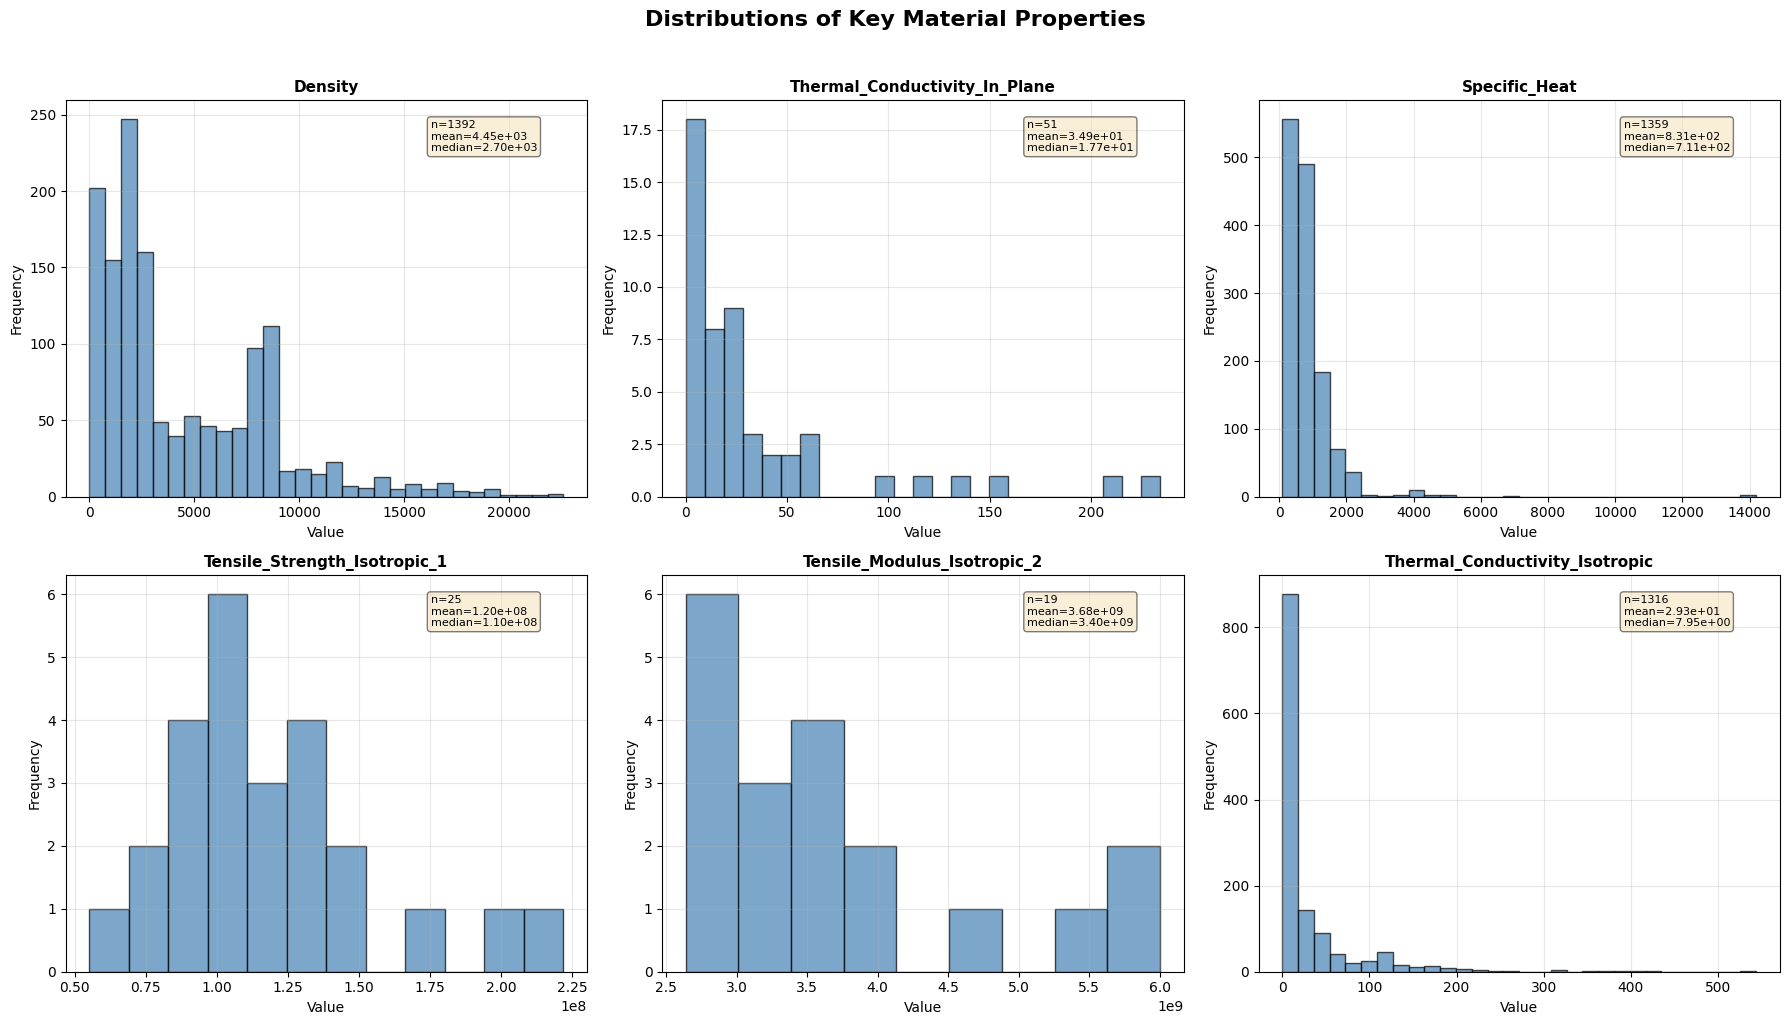

In [22]:
# Visualize distributions of key material properties
key_properties = ['Density_Value', 'Thermal_Conductivity_In_Plane_Value', 
                  'Specific_Heat_Value', 'Tensile_Strength_Isotropic_1_Value',
                  'Tensile_Modulus_Isotropic_2_Value', 'Thermal_Conductivity_Isotropic_Value']

available_props = [p for p in key_properties if p in df.columns and df[p].notna().sum() > 10]

if available_props:
    n_props = len(available_props)
    cols = min(3, n_props)
    rows = (n_props + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    if n_props == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    else:
        axes = axes.flatten()
    
    for idx, prop in enumerate(available_props):
        data = df[prop].dropna()
        if len(data) > 0:
            axes[idx].hist(data, bins=min(30, len(data)//2), edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].set_title(f'{prop.replace("_Value", "")}', fontweight='bold', fontsize=11)
            axes[idx].set_xlabel('Value', fontsize=10)
            axes[idx].set_ylabel('Frequency', fontsize=10)
            axes[idx].grid(True, alpha=0.3)
            # Add statistics text
            stats_text = f'n={len(data)}\nmean={data.mean():.2e}\nmedian={data.median():.2e}'
            axes[idx].text(0.7, 0.95, stats_text, transform=axes[idx].transAxes,
                          fontsize=8, verticalalignment='top', 
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Hide unused subplots
    for idx in range(len(available_props), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Distributions of Key Material Properties', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No key properties available for visualization (need at least 10 non-null values)")


PROPERTY COVERAGE ANALYSIS


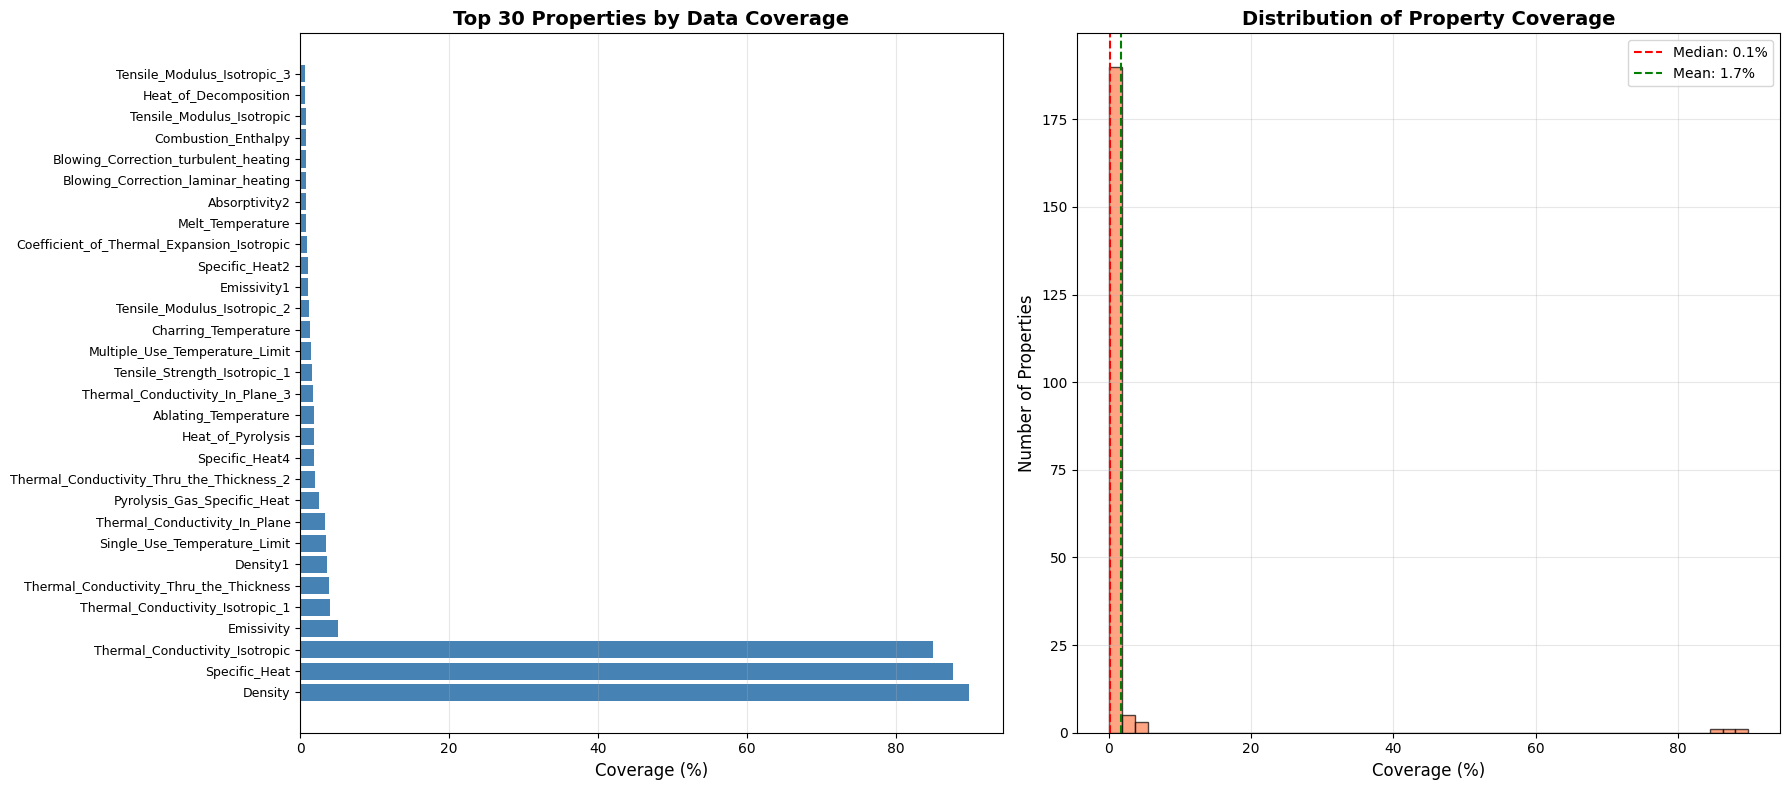


Property Coverage Statistics:
  Mean coverage: 1.68%
  Median coverage: 0.13%
  Max coverage: 89.86%
  Min coverage: 0.06%

Properties with >50% coverage: 3
Properties with >10% coverage: 3
Properties with >1% coverage: 21


In [23]:
# Property coverage analysis
print("=" * 80)
print("PROPERTY COVERAGE ANALYSIS")
print("=" * 80)

# Calculate coverage for all property value columns
coverage_data = []
for col in property_value_cols:
    if col in df.columns:
        non_null = df[col].notna().sum()
        coverage = non_null / len(df) * 100
        coverage_data.append({
            'Property': col.replace('_Value', ''),
            'Coverage': coverage,
            'Non_Null': non_null
        })

coverage_df = pd.DataFrame(coverage_data).sort_values('Coverage', ascending=False)

# Visualize property coverage
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 30 properties by coverage
top_30 = coverage_df.head(30)
axes[0].barh(range(len(top_30)), top_30['Coverage'], color='steelblue')
axes[0].set_yticks(range(len(top_30)))
axes[0].set_yticklabels(top_30['Property'], fontsize=9)
axes[0].set_xlabel('Coverage (%)', fontsize=12)
axes[0].set_title('Top 30 Properties by Data Coverage', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Coverage distribution
axes[1].hist(coverage_df['Coverage'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Coverage (%)', fontsize=12)
axes[1].set_ylabel('Number of Properties', fontsize=12)
axes[1].set_title('Distribution of Property Coverage', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(coverage_df['Coverage'].median(), color='red', linestyle='--', 
                label=f'Median: {coverage_df["Coverage"].median():.1f}%')
axes[1].axvline(coverage_df['Coverage'].mean(), color='green', linestyle='--', 
                label=f'Mean: {coverage_df["Coverage"].mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nProperty Coverage Statistics:")
print(f"  Mean coverage: {coverage_df['Coverage'].mean():.2f}%")
print(f"  Median coverage: {coverage_df['Coverage'].median():.2f}%")
print(f"  Max coverage: {coverage_df['Coverage'].max():.2f}%")
print(f"  Min coverage: {coverage_df['Coverage'].min():.2f}%")
print(f"\nProperties with >50% coverage: {len(coverage_df[coverage_df['Coverage'] > 50])}")
print(f"Properties with >10% coverage: {len(coverage_df[coverage_df['Coverage'] > 10])}")
print(f"Properties with >1% coverage: {len(coverage_df[coverage_df['Coverage'] > 1])}")


FEATURE ENGINEERING

Property completeness score created
Mean completeness: 0.0168
Std completeness: 0.0092
Min completeness: 0.0000
Max completeness: 0.1144


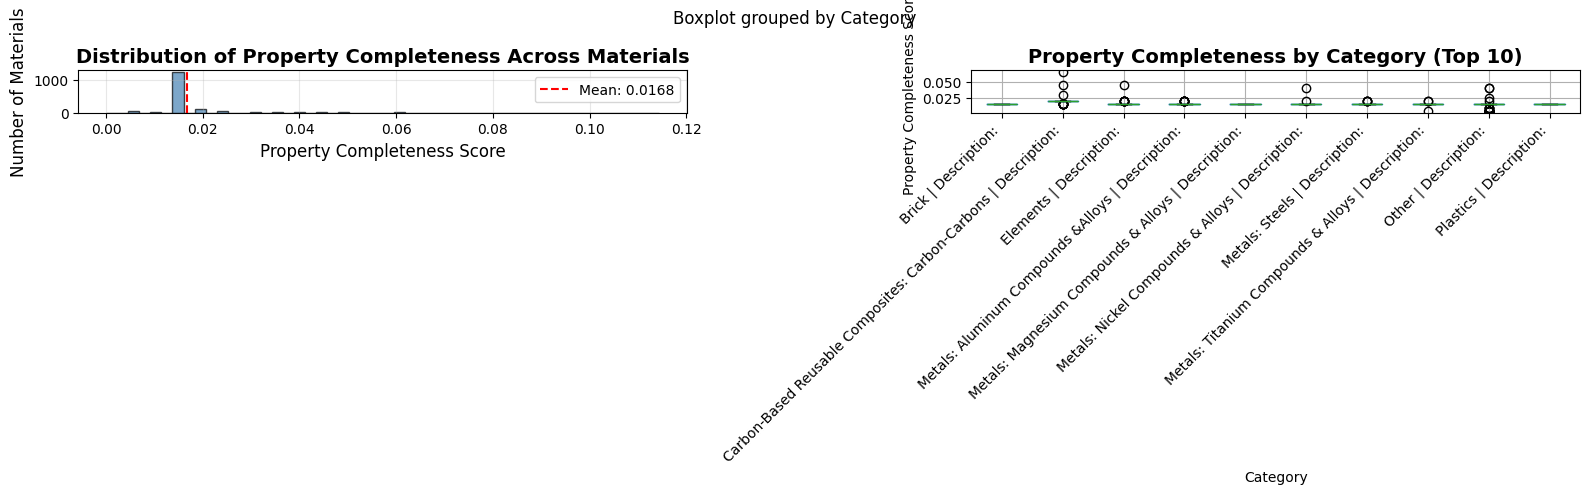

In [24]:
# Feature Engineering: Create consolidated material property features
print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Create a copy for feature engineering
df_fe = df.copy()

# 1. Extract base property names (remove suffixes like _Value, _Units, etc.)
def extract_base_property(col_name):
    """Extract base property name from column name"""
    suffixes = ['_Value', '_Units', '_Uncertainty', '_Source', '_STP', '_Reference', '_Last_Modified']
    for suffix in suffixes:
        if col_name.endswith(suffix):
            return col_name.replace(suffix, '')
    return col_name

# 2. Create property completeness score (how many properties are available per material)
property_value_cols_available = [col for col in property_value_cols if col in df_fe.columns]
df_fe['property_completeness'] = df_fe[property_value_cols_available].notna().sum(axis=1) / len(property_value_cols_available)

print(f"\nProperty completeness score created")
print(f"Mean completeness: {df_fe['property_completeness'].mean():.4f}")
print(f"Std completeness: {df_fe['property_completeness'].std():.4f}")
print(f"Min completeness: {df_fe['property_completeness'].min():.4f}")
print(f"Max completeness: {df_fe['property_completeness'].max():.4f}")

# Visualize completeness distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_fe['property_completeness'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Property Completeness Score', fontsize=12)
axes[0].set_ylabel('Number of Materials', fontsize=12)
axes[0].set_title('Distribution of Property Completeness Across Materials', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(df_fe['property_completeness'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df_fe["property_completeness"].mean():.4f}')
axes[0].legend()

# Box plot by category if available
if 'Category' in df_fe.columns:
    # Get top categories
    top_cats = df_fe['Category'].value_counts().head(10).index
    df_top_cats = df_fe[df_fe['Category'].isin(top_cats)]
    
    if len(df_top_cats) > 0:
        df_top_cats.boxplot(column='property_completeness', by='Category', ax=axes[1], rot=45)
        axes[1].set_title('Property Completeness by Category (Top 10)', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Category', fontsize=10)
        axes[1].set_ylabel('Property Completeness Score', fontsize=10)
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    else:
        axes[1].axis('off')
else:
    axes[1].axis('off')

plt.tight_layout()
plt.show()


In [25]:
# Correlation analysis for top properties
print("=" * 80)
print("PROPERTY CORRELATION ANALYSIS")
print("=" * 80)

# Select properties with reasonable coverage (>5%) for correlation analysis
high_coverage_props = [p for p, cov in sorted_properties[:30] if cov > 0.05]

if len(high_coverage_props) >= 5:
    # Calculate correlation matrix
    corr_matrix = df[high_coverage_props].corr()
    
    # Visualize correlation heatmap
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                xticklabels=[p.replace('_Value', '')[:20] for p in high_coverage_props],
                yticklabels=[p.replace('_Value', '')[:20] for p in high_coverage_props])
    plt.title('Correlation Matrix of Top Material Properties', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Find highly correlated pairs
    print(f"\nHighly correlated property pairs (|correlation| > 0.7):")
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7 and not np.isnan(corr_val):
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_val
                ))
    
    if high_corr_pairs:
        for prop1, prop2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
            print(f"  {prop1.replace('_Value', '')[:40]:40s} <-> {prop2.replace('_Value', '')[:40]:40s} : {corr:.3f}")
    else:
        print("  No highly correlated pairs found (threshold: 0.7)")
else:
    print("Not enough properties with sufficient coverage for correlation analysis")


PROPERTY CORRELATION ANALYSIS
Not enough properties with sufficient coverage for correlation analysis


In [26]:
# Summary Statistics and Data Quality Assessment
print("=" * 80)
print("DATA QUALITY SUMMARY")
print("=" * 80)

print(f"\nDataset Overview:")
print(f"  - Total materials: {len(df):,}")
print(f"  - Total features: {len(df.columns):,}")
print(f"  - Numeric features: {len(numeric_cols):,}")
print(f"  - Categorical features: {len(cat_cols):,}")
print(f"  - Text features: {len(text_cols):,}")

print(f"\nData Completeness:")
total_cells = len(df) * len(df.columns)
missing_cells = df.isnull().sum().sum()
completeness = (1 - missing_cells / total_cells) * 100
print(f"  - Overall completeness: {completeness:.2f}%")
print(f"  - Missing cells: {missing_cells:,} ({missing_cells/total_cells*100:.2f}%)")

print(f"\nProperty Coverage:")
print(f"  - Total property value columns: {len(property_value_cols)}")
print(f"  - Properties with data: {len(valid_property_cols)}")
if len(coverage_df) > 0:
    print(f"  - Mean property coverage: {coverage_df['Coverage'].mean():.2f}%")
    print(f"  - Properties with >10% coverage: {len(coverage_df[coverage_df['Coverage'] > 10])}")
    print(f"  - Properties with >50% coverage: {len(coverage_df[coverage_df['Coverage'] > 50])}")

print(f"\nMaterial Completeness:")
if 'property_completeness' in df_fe.columns:
    print(f"  - Mean property completeness per material: {df_fe['property_completeness'].mean():.4f}")
    print(f"  - Materials with >10% properties: {len(df_fe[df_fe['property_completeness'] > 0.1]):,}")
    print(f"  - Materials with >50% properties: {len(df_fe[df_fe['property_completeness'] > 0.5]):,}")

print(f"\nKey Categorical Features:")
for col in ['Category', 'Database_Source', 'Manufacturer']:
    if col in df.columns:
        print(f"  - {col}: {df[col].nunique()} unique values, "
              f"{df[col].isnull().sum()} missing ({df[col].isnull().sum()/len(df)*100:.1f}%)")

print(f"\n✓ EDA completed successfully!")
print(f"✓ Dataset is ready for further preprocessing and GNN modeling!")


DATA QUALITY SUMMARY

Dataset Overview:
  - Total materials: 1,549
  - Total features: 1,287
  - Numeric features: 467
  - Categorical features: 810
  - Text features: 10

Data Completeness:
  - Overall completeness: 2.46%
  - Missing cells: 1,944,580 (97.54%)

Property Coverage:
  - Total property value columns: 201
  - Properties with data: 201
  - Mean property coverage: 1.68%
  - Properties with >10% coverage: 3
  - Properties with >50% coverage: 3

Material Completeness:
  - Mean property completeness per material: 0.0168
  - Materials with >10% properties: 4
  - Materials with >50% properties: 0

Key Categorical Features:
  - Category: 80 unique values, 0 missing (0.0%)
  - Database_Source: 4 unique values, 0 missing (0.0%)
  - Manufacturer: 107 unique values, 4 missing (0.3%)

✓ EDA completed successfully!
✓ Dataset is ready for further preprocessing and GNN modeling!


CATEGORY DISTRIBUTION ANALYSIS


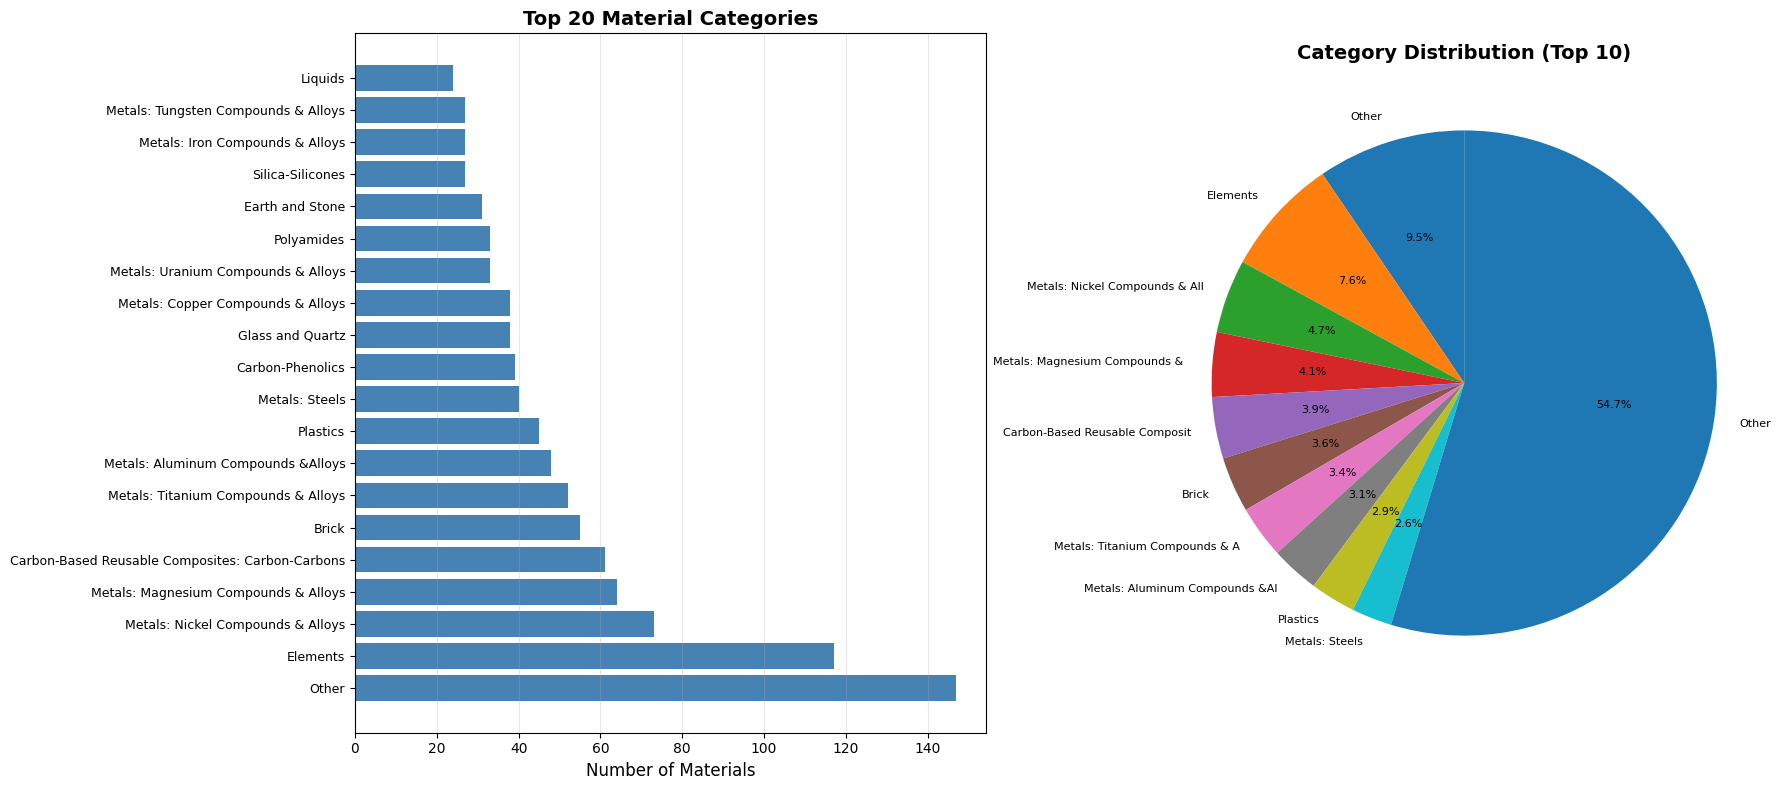


Total unique categories: 76

Top 10 categories:
 1. Other                                                        :  147 ( 9.49%)
 2. Elements                                                     :  117 ( 7.55%)
 3. Metals: Nickel Compounds & Alloys                            :   73 ( 4.71%)
 4. Metals: Magnesium Compounds & Alloys                         :   64 ( 4.13%)
 5. Carbon-Based Reusable Composites: Carbon-Carbons             :   61 ( 3.94%)
 6. Brick                                                        :   55 ( 3.55%)
 7. Metals: Titanium Compounds & Alloys                          :   52 ( 3.36%)
 8. Metals: Aluminum Compounds &Alloys                           :   48 ( 3.10%)
 9. Plastics                                                     :   45 ( 2.91%)
10. Metals: Steels                                               :   40 ( 2.58%)


In [27]:
# Category distribution visualization
if 'Category' in df.columns:
    print("=" * 80)
    print("CATEGORY DISTRIBUTION ANALYSIS")
    print("=" * 80)
    
    # Clean category names (remove "| Description:" suffix if present)
    df['Category_clean'] = df['Category'].str.replace(' | Description:', '', regex=False)
    
    category_counts = df['Category_clean'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Bar chart
    top_20 = category_counts.head(20)
    axes[0].barh(range(len(top_20)), top_20.values, color='steelblue')
    axes[0].set_yticks(range(len(top_20)))
    axes[0].set_yticklabels([str(x)[:50] for x in top_20.index], fontsize=9)
    axes[0].set_xlabel('Number of Materials', fontsize=12)
    axes[0].set_title('Top 20 Material Categories', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Pie chart for top 10
    top_10 = category_counts.head(10)
    other_count = category_counts.iloc[10:].sum() if len(category_counts) > 10 else 0
    if other_count > 0:
        pie_data = list(top_10.values) + [other_count]
        pie_labels = [str(x)[:30] for x in top_10.index] + ['Other']
    else:
        pie_data = top_10.values
        pie_labels = [str(x)[:30] for x in top_10.index]
    
    axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
    axes[1].set_title('Category Distribution (Top 10)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal unique categories: {df['Category_clean'].nunique()}")
    print(f"\nTop 10 categories:")
    for i, (cat, count) in enumerate(category_counts.head(10).items(), 1):
        pct = count / len(df) * 100
        print(f"{i:2d}. {str(cat)[:60]:60s} : {count:4d} ({pct:5.2f}%)")


DATABASE SOURCE DISTRIBUTION


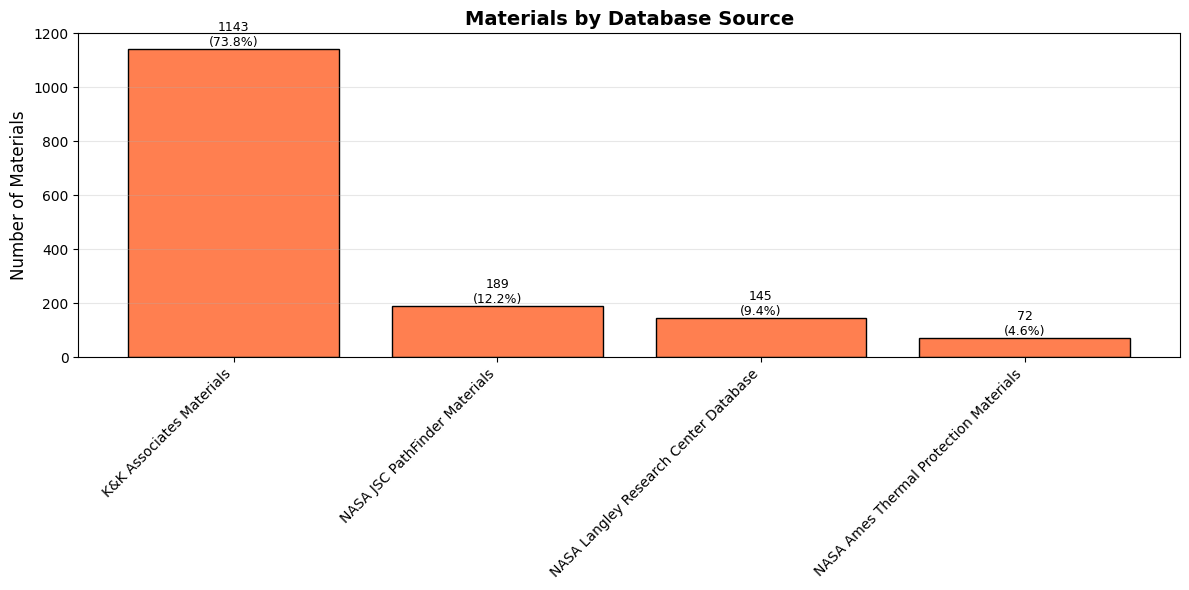


Database sources: 4
  K&K Associates Materials                                     : 1143 (73.79%)
  NASA JSC PathFinder Materials                                :  189 (12.20%)
  NASA Langley Research Center Database                        :  145 ( 9.36%)
  NASA Ames Thermal Protection Materials                       :   72 ( 4.65%)


In [28]:
# Database Source distribution
if 'Database_Source' in df.columns:
    print("=" * 80)
    print("DATABASE SOURCE DISTRIBUTION")
    print("=" * 80)
    
    db_counts = df['Database_Source'].value_counts()
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    bars = ax.bar(range(len(db_counts)), db_counts.values, color='coral', edgecolor='black')
    ax.set_xticks(range(len(db_counts)))
    ax.set_xticklabels([str(x)[:40] for x in db_counts.index], rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Number of Materials', fontsize=12)
    ax.set_title('Materials by Database Source', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, count) in enumerate(zip(bars, db_counts.values)):
        height = bar.get_height()
        pct = count / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nDatabase sources: {len(db_counts)}")
    for db, count in db_counts.items():
        pct = count / len(df) * 100
        print(f"  {str(db):60s} : {count:4d} ({pct:5.2f}%)")


## Key Insights and Recommendations

### Data Quality
- **Dataset Size**: Large dataset with 1500+ materials and 1287 features
- **Sparsity**: High sparsity expected in material property data
- **Completeness**: Property coverage varies significantly across materials

### Next Steps for GNN Modeling
1. **Feature Selection**: Select properties with >10% coverage for initial modeling
2. **Missing Value Handling**: Use appropriate imputation strategies (median, mean, or advanced methods)
3. **Graph Construction**: Build similarity graphs based on property values
4. **Feature Engineering**: Create aggregated features and normalize property values
5. **Model Architecture**: Design GNN architecture suitable for sparse material property data
